## RandomForest Classifier
    Building classification models on the Mobile Price Classification dataset to predict the price range of a mobile phone.

## Step1: Data Gathering

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
path = r'https://raw.githubusercontent.com/akash-ostwal/Datasets/refs/heads/main/Mobile%20Price-train.csv'
import pandas as pd
df = pd.read_csv(path)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Step2: Performing basic data quality checks

In [3]:
df.shape

(2000, 21)

In [4]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df=df.drop_duplicates()

## Step3: Separating data into X and Y features

In [9]:
X = df.drop(columns='price_range')
Y = df[['price_range']]

In [10]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [11]:
Y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


## Step4 : Data Preprocessing and Data cleaning

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [13]:
pre = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')

In [14]:
pre

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [15]:
X_pre = pre.fit_transform(X)
X_pre.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099


## Step5: Spliting data into training and testing

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.7,random_state=30)

In [18]:
xtrain.shape

(1400, 20)

In [19]:
xtrain.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1995,-1.011860,1.010051,-1.253064,0.981177,-0.992890,0.957886,-1.656260,1.034357,-0.967737,0.646842,0.673534,1.300273,1.477661,-1.342799,0.164641,-0.405712,1.462493,0.559641,0.994018,-1.014099
1951,0.201411,-0.990050,1.566254,-1.019184,1.311067,-1.043966,-0.498672,-0.006069,-1.448088,1.084046,1.003414,-0.460045,1.086540,-1.154687,-1.259796,-0.176107,-1.283457,0.559641,0.994018,0.986097
23,0.827395,1.010051,1.566254,0.981177,-0.071307,0.957886,0.328176,0.687548,-0.741690,-0.664768,1.663176,-0.403697,-1.072726,-1.002538,-1.022389,0.283103,1.645557,0.559641,-1.006018,-1.014099
1720,0.021583,-0.990050,1.075937,-1.019184,0.389484,0.957886,-1.270397,-0.352878,-1.448088,-0.664768,-0.316108,-1.293998,1.005538,0.304102,-0.784983,0.512708,0.364113,0.559641,0.994018,-1.014099
916,-0.961781,1.010051,-1.253064,-1.019184,-0.071307,-1.043966,-0.994781,1.381165,1.631808,-0.664768,0.508594,-1.118192,-1.605020,-1.020058,1.114266,0.971917,0.730240,0.559641,-1.006018,-1.014099


In [20]:
xtest.shape

(600, 20)

In [21]:
xtest.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1856,1.246235,-0.990050,1.321096,-1.019184,0.389484,-1.043966,-0.994781,1.727974,-0.713434,-0.227564,0.838474,-0.065607,-0.785749,0.842619,1.351672,-1.324131,0.547176,0.559641,-1.006018,-1.014099
364,-0.734151,1.010051,1.321096,-1.019184,-0.992890,-1.043966,0.217930,-0.699686,1.547040,-0.227564,0.343653,-1.030289,-0.600603,-0.603261,0.164641,-1.324131,0.547176,-1.786861,0.994018,-1.014099
1948,-1.116570,-0.990050,-0.149853,-1.019184,-0.992890,-1.043966,-0.388426,1.727974,-0.854714,1.084046,0.673534,-1.255681,-1.255557,-0.138514,1.114266,-0.176107,0.364113,-1.786861,0.994018,0.986097
1458,0.294739,-0.990050,-1.253064,-1.019184,1.311067,0.957886,0.548669,-1.046495,-1.391576,-1.539175,1.663176,0.590286,-0.755663,-0.492607,-0.072765,-1.324131,0.547176,0.559641,-1.006018,-1.014099
609,-0.060364,-0.990050,1.321096,-1.019184,-0.762495,0.957886,0.769162,-0.699686,-1.080761,-0.227564,-0.316108,-0.076877,1.072654,0.115068,0.402047,-0.635317,-1.283457,0.559641,0.994018,0.986097


In [22]:
ytrain.head()

,price_range
1995,0
1951,0
23,0
1720,2
916,0


In [23]:
ytest.head()

,price_range
1856,3
364,0
1948,1
1458,1
609,2


## Step6: Model building

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
model = RandomForestClassifier(
    n_estimators=5,
    max_depth=4,
    min_samples_leaf=2,
    min_samples_split=5,
    criterion='gini'
)
model.fit(xtrain,ytrain)

,n_estimators,5
,criterion,'gini'
,max_depth,4
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
model.score(xtrain,ytrain)

0.7792857142857142

In [27]:
model.score(xtest,ytest)

0.7216666666666667

**Hyperparameter tuning- overfitting scenario, choose the best parameters required for the model**

In [28]:
params = {
    'n_estimators':[5,10,35,50,75,100,150],
    'max_depth':[3,5,7,9,11]
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
base_model = RandomForestClassifier()
rscv = RandomizedSearchCV(estimator=base_model,param_distributions=params,cv=3,scoring='f1_macro')
rscv.fit(xtrain,ytrain)

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [3, 5, ...], 'n_estimators': [5, 10, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [31]:
rscv.best_params_

{'n_estimators': 75, 'max_depth': 9}

In [32]:
rscv.best_score_

np.float64(0.8663298406493635)

In [33]:
best_rfc = rscv.best_estimator_

In [34]:
best_rfc.score(xtrain,ytrain)

0.9942857142857143

In [35]:
best_rfc.score(xtest,ytest)

0.8566666666666667

## Step7: Model Evaluation

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

In [37]:
ypred_test = model.predict(xtest)
ypred_test[:5]

array([3, 1, 1, 1, 2])

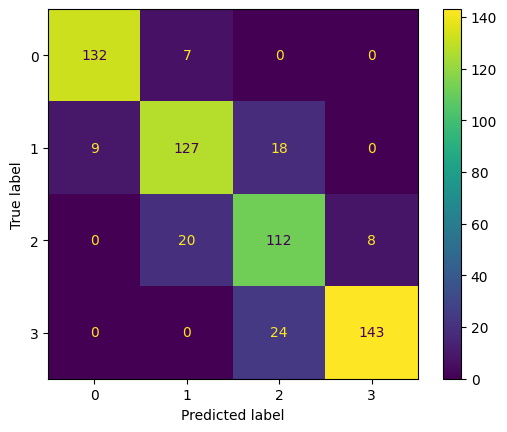

In [38]:
ConfusionMatrixDisplay.from_estimator(best_rfc,xtest,ytest)

In [39]:
from sklearn.metrics import classification_report

In [40]:
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       139
           1       0.66      0.68      0.67       154
           2       0.61      0.55      0.58       140
           3       0.80      0.83      0.81       167

    accuracy                           0.72       600
   macro avg       0.72      0.72      0.72       600
weighted avg       0.72      0.72      0.72       600



## class1 & class2 are performing poorly, also there is a noticeable imbalance in class-wise performance. so this model will not be considered for the final model building.